<center>
    <img src="https://raw.githubusercontent.com/dvgodoy/PyTorch101_ODSC_Europe2020/master/images/linear_dogs.jpg" width="900">
</center>

# Yet another math for ML course

# Домашнее задание 1: Векторы, матрицы и геометрия эмбеддингов


Всё современное машинное обучение стоит на одной идее: любой объект — картинку, текст, граф — можно превратить в вектор.

Зачем это нужно:

- компьютер умеет только считать;
- в числа можно упаковать смысл.

Можно попробовать превратить слова в цифры с помощью бинаризации, one-hot encoding. Для этого надо занумеровать словарь и для каждого слова поставить единичку на месте его номера. Остальные позиции заполним нулями. Компьютер сможет обрабатывать такие последовательности, правда смысла в них не будет: «кошка» в пространстве таких векторов будет лежать настолько же далеко от «котёнка», как от «синхрофазотрона».

Идея эмбеддингов позволяет запаковать слова в вектора по-умному. Нейронная сетка учится упаковывать слова в вектора так, чтобы близость в пространстве отражала близость по смыслу. Причём модель во время обучения делает это исходя из статистики того, какие слова стоят рядом с какими.

Смысл превращается в геометрию: похожесть — это угол, тема — область пространства. А норма, ранг и определитель перестают быть абстракциями из учебника и начинают что-то говорить про данные.

В этой домашке мы с вами попробуем немного поработать с пространством эмбеддингов и наложим на него определения с лекции по линалу, а именно:

- расчехлим древний баян и посчитаем `king - man + woman`;
- проверим на данных гипотезу из настоящей статьи о том, что означает длина вектора слова;
- поймём, почему в поиске по эмбеддингам берут косинус, а не привычное евклидово расстояние;
- разберёмся, что обозначают ранг и определитель матрицы и при чем тут линейная независимость.

Всего за задание можно получить 10 баллов.

_Благодарим Сабрину Садих за составление этого домашнего задания._


In [1]:
%pip install -q gensim numpy pandas matplotlib seaborn scipy


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gensim.downloader as api

from scipy.stats import pearsonr, spearmanr

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

np.random.seed(42)

### Формат проверки работы: peer review.

Каждая работа проверяется пятью вашими случайно выбранными однокурсниками. Вы также обязаны проверить пять чужих работ.

Проверяющий выставляет баллы по критериям из задания и оставляет содержательные комментарии: что сделано хорошо, где есть ошибки, что стоит исправить.

Итоговая оценка за задание складывается из трёх частей:

$$
\text{Оценка} = 0.8 \cdot \text{Решение} + 0.1 \cdot \text{Полезность ревью} + 0.1 \cdot \text{Согласованность ревью}
$$

- **80% решение** — это баллы за вашу собственную работу, полученные при проверке.
- **10% полезность ревью** — после проверки авторы работ оценивают, насколько полезными были полученные комментарии. Хорошее ревью должно быть конкретным, вежливым и помогать понять ошибки. Комментарии вида «всё ок», «неверно», «плохо» без объяснений считаются бесполезными.
- **10% согласованность ревью** — оценка проверяющего сравнивается с оценками других проверяющих. Если ваши баллы систематически сильно отличаются от общего консенсуса без убедительных комментариев, эта часть оценки снижается.

Максимум за домашку — 10 баллов, плюс 1 бонусный: 0.5 за задание 0 и 0.5 за задание 4\*. Итого можно набрать 11. Почти под каждым заданием есть вопросы. Ответы на них — часть задания и оцениваются наравне с кодом: работающий код с пустым «Ответ:» полного балла не получает.


Можно:

- указывать на ошибки и спорные места;
- снижать баллы, если решение не соответствует критериям;
- давать рекомендации по исправлению;
- писать развёрнутые комментарии по существу.

Нельзя:

- ставить баллы случайно или всем одинаково;
- писать формальные комментарии без содержания;
- оскорблять автора работы;
- договариваться о взаимных оценках;
- просить других поставить вам определённый балл;
- использовать peer review как способ отомстить или помочь друзьям.

Проверка тоже является частью задания. Халтурные, пустые или недобросовестные ревью будут снижать итоговый балл. Конкретные способы расчёта согласованности и полезности ревью не раскрываются.


Давайте попробуем сходу освоиться в системе и сделаем бонусное задание на бонусные баллы!


**(0.5 балла, бонус) Задание 0: знакомство**

**ФИО:**

**Напиши три факта о себе.** Один из них должен быть неправдой. Пусть проверяющие домашки угадают, какой:

1. У меня есть статья на A\* конфе.
2. Почти каждый раз, когда я приходил в Аэроплан, я видел там Фила Ульянкина.
3. Я не умею кататься на коньках.

**Картинка, которая описывает вас лучше слов.** Вставьте её сюда: мем, фото котика, любимый график — что угодно.

[![нажмите сюда для фоточки]](https://disk.360.yandex.ru/i/J9Pg8Ok2N-UWNg)


> **Для ревьюеров:** полный балл — если есть три факта и картинка. Скучные факты и скучная картинка баллы не снижают. Отсутствие картинки — снижает. В комментарии напишите, какой факт вы посчитали неправдой: угадали вы или нет — на оценку не влияет. Не забудьте поделиться упоротыми находками с чатиком.


В рамках этой домашки мы будем работать с моделью `GloVe` — эмбеддингами, обученными на Википедии и корпусе новостей. Внутри модели лежит обычная таблица чисел размера $400000 \times 300$. В каждой строчке лежит эмбеддинг конкретного слова. Достать вектор слова можно командой `model[word]`.


In [ ]:
model = api.load("glove-wiki-gigaword-300")
print(f"Словарь: {len(model.index_to_key)} слов, размерность: {model.vector_size}")

Словарь: 400000 слов, размерность: 300


In [ ]:
model["cat"].shape  # каждое слово описывается вектором размера 300

(300,)

In [ ]:
model.index_to_key[:10]  # слова отсортированные по частоте

['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s"]

In [ ]:
model.key_to_index["great"]  # порядковый номер слова в словаре

353

Всё дальнейшее — арифметика и геометрия над строками этой таблицы.


## 1. Разминка — пощупаем пространство эмбеддингов

Прежде чем проверять гипотезы из статей, потрогаем руками, что лежит в этих 300 числах и какие операции над ними осмысленны. Давайте посмотрим подробнее на вектор, описывающий кошку.


Первые 10 координат: [-0.294  0.332 -0.047 -0.122  0.072 -0.234 -0.062 -0.004 -0.395 -0.694]
Размерность: 300
L2-норма: 6.33


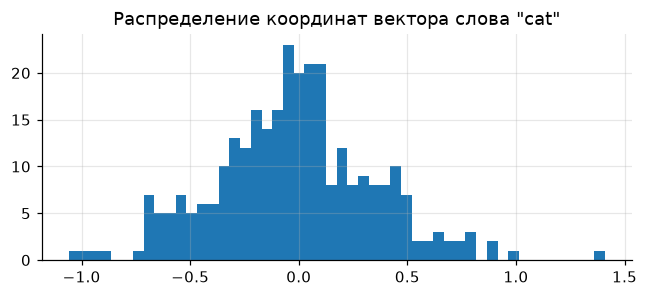

In [7]:
v = model["cat"]

print("Первые 10 координат:", np.round(v[:10], 3))
print(f"Размерность: {v.shape[0]}")
print(f"L2-норма: {np.linalg.norm(v):.2f}")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.hist(v, bins=50)
ax.set_title('Распределение координат вектора слова "cat"')
plt.tight_layout()
plt.show()

Внутри — 300 чисел вокруг нуля, и ни одно из них не подписано «пушистость» или «домашнее животное».

Так где же в векторе спрятан смысл слова?


**(0.5 балла) Задание 1:** Проверим, значит ли что-нибудь отдельная координата.

Выберите координату `k` и выведите 10 слов с самым большим значением по ней. Повторите для четырёх разных `k` и попытайтесь понять, есть ли в этих списках хоть что-то осмысленное.


In [ ]:
for coordinate in [0, 50, 100, 200]:
    values = model.vectors[:, coordinate]
    top_indices = np.argsort(values)[-10:][::-1]
    print(coordinate, [model.index_to_key[index] for index in top_indices])

0 ['2001-2011', 'governmentally', 'ubogu', 'hah', 'darroll', 'overextend', 'tarabini', 'bereket', 'castrogiovanni', 'fritillary']


50 ['crites', '202-383-7824', 'eurodollar', '.714', 'terminboerse', 'deveined', 'raions', 'equatoria', 'liezel', 'tamika']


100 ['granollers', 'lance-shaped', 'pelzer', 'geoana', 'flycatchers', 'insectivorous', 'prensa', 'telethon', 'lautenberg', 'flycatcher']
200 ['championship', 'champion', 'colspan', 'championships', 'cup', 'debut', 'tournament', 'finals', 'career', 'golden']


Теперь давайте попробуем сделать то же самое, но вдоль «направления» между векторами. Найдите направление `d = model["huge"] - model["small"]`.

Поделите `d` на его длину и посчитайте `X @ d`. Для каждого слова получится одно число: насколько далеко оно уехало вдоль `d`. Выведите по 10 слов с обоих концов.

Кстати, это число называется проекцией вектора `x` на направление `d`.


In [ ]:
direction = model["huge"] - model["small"]
direction = direction / np.linalg.norm(direction)
projections = model.vectors @ direction
sorted_indices = np.argsort(projections)

print("большие проекции:", [model.index_to_key[i] for i in sorted_indices[-10:][::-1]])
print("маленькие проекции:", [model.index_to_key[i] for i in sorted_indices[:10]])

большие проекции: ['huge', 'massive', 'shtokman', 'enormous', 'interés', '700-billion', '787-billion', 'kovykta', 'tremendous', 'immense']
маленькие проекции: ['nucleolar', 'insectivorous', 'small', 'craterlets', 'plumaged', 'administaff', 'passerine', 'gastropod', 'air-breathing', 'medium-large']


**Вопрос:** стал ли список слов более осмысленным? Что это говорит о том, где живёт смысл — в осях координат или в направлениях?

**Ответ:** ну да. самые большие проекции связаны с `huge` и `massive`, а среди самых маленьких есть `small`. смысл живёт скорее в направлениях, потому что одна или две координаты показывают лишь часть информации.


> **Для ревьюеров:** 0.25 — топы по четырём координатам и по проекции на `huge − small`, 0.25 — ответ на вопрос. Во всех заданиях ниже баллы делятся поровну между кодом и ответом, если не указано иное.


**(0.5 балла) Задание 2:** Что делает с вектором умножение на число?

Найдите 5 ближайших соседей слова `cat` через `model.similar_by_vector` для `v`, `3 * v` и `0.1 * v`. И отдельно для `-v`.


In [ ]:
cat_vector = model["cat"]
for multiplier in [1, 3, 0.1, -1]:
    neighbors = model.similar_by_vector(multiplier * cat_vector, topn=6)
    words = [word for word, score in neighbors if word != "cat"][:5]
    print(multiplier, words)

1 ['dog', 'cats', 'pet', 'dogs', 'feline']
3 ['dog', 'cats', 'pet', 'dogs', 'feline']
0.1 ['dog', 'cats', 'pet', 'dogs', 'feline']
-1 ['nucleation', '2,780', 'i-29', 'pichler', '27,100']


**Вопрос:** что происходит со списками? Они совпали?

- Объясните результат через формулу косинуса;
- Что случилось с `-v`;
- Означает ли всё это, что длина вектора не несёт никакой информации?

**Ответ:** ага, для v, 3v и 0.1v списки совпали. в формуле косинуса при умножении на положительное число числитель и знаменатель меняются одинаково, поэтому косинус остается тем же. для -v направление стало противоположным, косинус сменил знак и соседние знач стали другими. это не значит что длина бесполезна, просто поиск по косинусу её не учитывает


**(0.5 балла) Задание 3:** А теперь сложение — усредним векторы.

1. Возьмите `drinks = ["tea", "coffee", "juice", "beer", "wine"]`, посчитайте среднее и выведите 10 ближайших к нему слов, выкинув из выдачи исходные.
2. Сделайте то же самое для `random_words = ["cat", "algebra", "tuesday", "volcano", "senator"]` — пять слов из разных областей. Можно взять свои, но пусть они действительно будут ни о чём общем.
3. Для обоих наборов сравните норму центроида со средней нормой слова в наборе.


In [ ]:
drinks = ["tea", "coffee", "juice", "beer", "wine"]
random_words = ["cat", "algebra", "tuesday", "volcano", "senator"]

for name, words in [("напитки", drinks), ("разные слова", random_words)]:
    vectors = model[words]
    centroid = vectors.mean(axis=0)
    neighbors = model.similar_by_vector(centroid, topn=10 + len(words))
    nearest_words = [word for word, score in neighbors if word not in words][:10]
    print(name, nearest_words)
    print(
        "норма среднего:",
        round(np.linalg.norm(centroid), 2),
        "средняя норма слова:",
        round(np.linalg.norm(vectors, axis=1).mean(), 2),
    )

напитки ['drink', 'drinks', 'fruit', 'beverage', 'wines', 'bottled', 'milk', 'bottle', 'sipping', 'vodka']
норма среднего: 5.5 средняя норма слова: 7.14
разные слова ['wednesday', 'monday', 'week', 'thursday', 'after', 'another', 'sunday', 'saturday', 'called', 'friday']
норма среднего: 3.37 средняя норма слова: 7.05


**Вопрос:** как можно проинтерпретировать точку, описывающую среднее нескольких векторов? Почему в первом случае соседи центроида получились осмысленными, а во втором нет? Почему норма у второго центроида заметно меньше, чем у первого?

**Ответ:** это как общая точка для нескольких слов. у напитков есть общая тема, поэтому рядом со средним оказались drink и beverage. у второго набора общей темы нет, хотя результат немного потянуло к дням недели изза tuesday. векторы смотрят в разные стороны и частично гасят друг друга, поэтому средний вектор короче


**(1 балл) Задание 4:** Наконец вычтем из короля мужчину и прибавим женщину.

Напишите функцию `analogy(a, b, c)` — «`a` относится к `b` так же, как `c` относится к чему?».

Берём `model[b] - model[a] + model[c]`, ищем ближайшие к получившемуся результату слова, а сами `a`, `b`, `c` из выдачи выкидываем.

Проверьте на трёх примерах: `("france", "paris", "italy")`, `("man", "king", "woman")`, `("good", "better", "bad")`.


In [ ]:
def analogy(a, b, c):
    result_vector = model[b] - model[a] + model[c]
    neighbors = model.similar_by_vector(result_vector, topn=13)
    return [word for word, score in neighbors if word not in [a, b, c]][:10]


for a, b, c in [
    ("france", "paris", "italy"),
    ("man", "king", "woman"),
    ("good", "better", "bad"),
]:
    print(a, b, c, "->", analogy(a, b, c))

france paris italy -> ['rome', 'milan', 'italian', 'turin', 'bologna', 'naples', 'venice', 'florence', 'vienna', 'genoa']
man king woman -> ['queen', 'monarch', 'throne', 'princess', 'mother', 'daughter', 'kingdom', 'prince', 'elizabeth', 'wife']


good better bad -> ['worse', 'things', 'gotten', 'actually', 'getting', 'because', 'harder', 'maybe', 'get', 'trouble']


**Вопрос:** что геометрически означает разность `model["paris"] - model["france"]`? Почему её вообще осмысленно прибавлять к другой стране — какое допущение о геометрии пространства здесь спрятано?

**Ответ:** это направление от страны к ее столице. мы отталкиваемя от того что у других стран переход похожий, поэтому прибавления italy дает рим


Мы предположили, что отношение — это одно и то же направление для всех пар. Давайте убедимся в этом.

Будем откладывать по оси X среднее направление отношения, а по оси Y — всё остальное. Если предположение верное, стрелки будут почти параллельны и одной длины.

Разберитесь в коде ниже и запустите его.


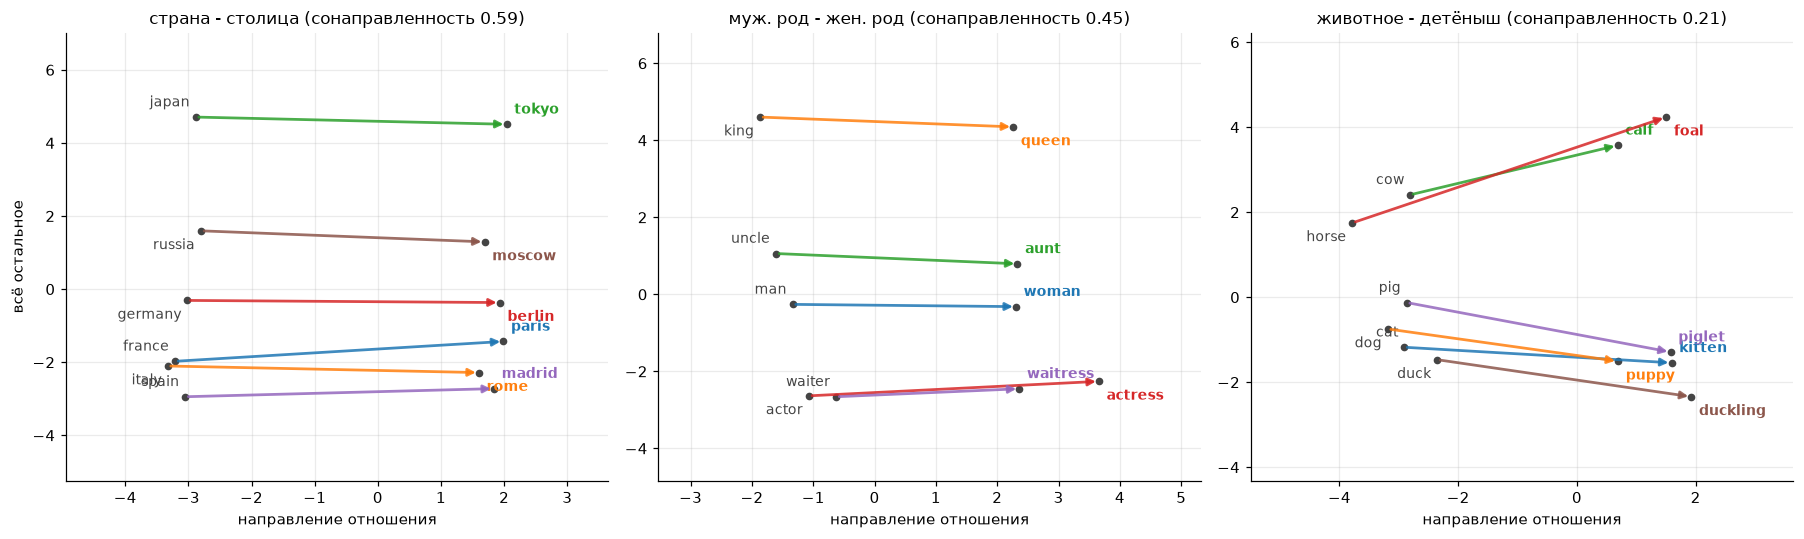

In [ ]:
def plot_pairs(ax, pairs, title):
    # d — вектор разности внутри пары, нормируем каждый на единичную длину
    D = np.array([model[b] - model[a] for a, b in pairs])
    Dn = D / np.linalg.norm(D, axis=1, keepdims=True)

    # u — среднее направление отношения, станет осью X
    u = Dn.mean(axis=0)
    u = u / np.linalg.norm(u)

    # ось Y — главное направление того, что осталось после вычитания u
    # что тут произошло и при чем тут SVD разберемся на будущих лекциях, приходите :)
    W = np.array([model[w] for pair in pairs for w in pair])
    R = W - np.outer(W @ u, u)
    R = R - R.mean(axis=0)
    v = np.linalg.svd(R, full_matrices=False)[2][0]

    x, y = W @ u, W @ v
    cos = np.mean([Dn[i] @ Dn[j] for i in range(len(pairs)) for j in range(i)])

    ax.scatter(x, y, s=16, color="#444", zorder=3)
    for i, (a, b) in enumerate(pairs):
        dy = 7 if i % 2 == 0 else -12  # разводим подписи, чтобы не наезжали
        ax.annotate(
            "",
            xy=(x[2 * i + 1], y[2 * i + 1]),
            xytext=(x[2 * i], y[2 * i]),
            arrowprops=dict(arrowstyle="-|>", lw=1.8, color=f"C{i}", alpha=0.85),
        )
        ax.annotate(
            a,
            (x[2 * i], y[2 * i]),
            textcoords="offset points",
            xytext=(-4, dy),
            fontsize=9,
            ha="right",
            color="#444",
        )
        ax.annotate(
            b,
            (x[2 * i + 1], y[2 * i + 1]),
            textcoords="offset points",
            xytext=(5, dy),
            fontsize=9,
            ha="left",
            weight="bold",
            color=f"C{i}",
        )
    ax.margins(0.30)
    ax.set_title(f"{title} (сонаправленность {cos:.2f})", fontsize=11)
    ax.set_xlabel("направление отношения")
    ax.grid(alpha=0.25)


country = [
    ("france", "paris"),
    ("italy", "rome"),
    ("japan", "tokyo"),
    ("germany", "berlin"),
    ("spain", "madrid"),
    ("russia", "moscow"),
]
gender = [
    ("man", "woman"),
    ("king", "queen"),
    ("uncle", "aunt"),
    ("actor", "actress"),
    ("waiter", "waitress"),
]
young = [
    ("cat", "kitten"),
    ("dog", "puppy"),
    ("cow", "calf"),
    ("horse", "foal"),
    ("pig", "piglet"),
    ("duck", "duckling"),
]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
for ax, (pairs, title) in zip(
    axes,
    [
        (country, "страна - столица"),
        (gender, "муж. род - жен. род"),
        (young, "животное - детёныш"),
    ],
):
    plot_pairs(ax, pairs, title)
axes[0].set_ylabel("всё остальное")
plt.tight_layout()
plt.show()

Для пар «страна - столица» стрелки почти параллельны и сопоставимой длины — среднее попарное косинусное сходство между ними $0.59.$ Ровно это и нужно, чтобы аналогия `france : paris = italy : ?` попадала в `rome`: смещение действительно одно и то же для разных стран.

У пар «муж. род - жен. род» согласованность чуть ниже (0.45), но картина та же.

А вот «животное - детёныш» разъезжается (0.21): стрелки расходятся веером и отличаются длиной. Слова `kitten`, `puppy`, `foal`, `duckling` встречаются в очень разных контекстах, поэтому единого направления в пространстве просто нет.

Отсюда мораль: аналогии работают ровно настолько, насколько регулярно отношение выражено в текстах. Это не свойство линала, а свойство корпуса текстов.


**(0.5 балла, бонус) Задание 4\*:** А теперь придумайте свою аналогию и проверьте модель на прочность.

Прогоните через `analogy` две-три своих тройки. Постарайтесь найти одну, где модель отвечает красиво, и одну, где она садится в лужу. В паре предложений объясните, почему, по-вашему, так вышло.

**Мои аналогии и что из них получилось:**

man : woman = batman : ? модель выдала catwoman, хотя я скорее ждал batwoman. видимо, batman и catwoman часто встречаются вместе. cat : kitten = pizza : ? модель выдала pepperoni. тут так сказать можно и напрячься, откуда cat в пеперони


In [ ]:
my_analogies = [("man", "woman", "batman"), ("cat", "kitten", "pizza")]

for a, b, c in my_analogies:
    print(a, b, c, "->", analogy(a, b, c))

man woman batman -> ['catwoman', 'superman', 'batgirl', 'batwoman', 'superhero', 'nightwing', 'supergirl', 'gotham', 'superheroes', 'spider-man']
cat kitten pizza -> ['pepperoni', 'pizzas', 'taco', 'deliveryman', 'dough', 'toppings', 'pizzeria', 'sandwiches', 'bagel', 'cheesecake']


> **Для ревьюеров:** бонус ставится за изобретательность, а не за то, что модель угадала. Тройки из условия не считаются. Если аналогия вас удивила или рассмешила, ставьте 0.5. Если модель везде промахнулась, а объяснения почему нет, ставьте 0.


**Разминка перед второй частью (не оценивается).** Как вы думаете, у каких слов вектор длиннее: у самых частых (`the`, `of`), у средних (`kitchen`, `volcano`) или у совсем редких? Запишите догадку одной строкой и не правьте её после решения.

**Ваша догадка:** ...


## 2. Норма вектора: что закодировано в длине

Мы знаем с лекции, что косинус длину игнорирует. Выше мы узнали, что в пространстве эмбеддингов смысл запакован в направления, поэтому расстояния между словами логично измерять в углах. Означает ли всё это, что длина - мусор и считать её вообще нет смысла?

Давайте разберёмся и воспроизведём результат статьи «Measuring Word Significance using Distributed Representations of Words» ([arXiv:1508.02297](https://arxiv.org/abs/1508.02297)).

Гипотеза авторов статьи заключается в том, что длина вектора говорит, насколько слово содержательно:

- редкие слова модель видела в паре примеров, вектор обучиться толком не успел — он короткий;
- сверхчастые `the`, `of`, `and` живут в огромном числе непохожих контекстов, их вектор оказывается усреднением всего подряд — и тоже короткий;
- а вот слова посередине — достаточно частые, но с узким кругом контекстов — должны быть самыми длинными.

Если гипотеза верна, зависимость нормы от частоты выглядит как горб. Авторы наблюдали его на word2vec, а мы проверим на GloVe — это другая модель, и совпадения результатов никто не гарантирует.


**(1 балл) Задание 5:** Если гипотеза верна, то у самых частых слов норма маленькая, у слов из середины словаря — большая, а у самых редких — снова маленькая.


Давайте нарисуем картинку: по оси X отложим частоты слов, а по оси Y среднюю норму. Делать это мы будем в логарифмической шкале, так как первые слова словаря отличаются друг от друга по частоте куда сильнее, чем стотысячное от стотысячепервое.

При таком разбиении и первая сотня слов, и последняя сотня тысяч попадут на график с одинаковой детализацией.

Границы групп посчитаем сразу — дальше будем брать соседние пары из `edges`: слова с номерами от `edges[0]` до `edges[1]`, потом от `edges[1]` до `edges[2]` и так далее.


In [15]:
vocab = model.index_to_key
n = len(vocab)
n

400000

In [16]:
edges = np.unique(np.geomspace(1, n, 40).astype(int))
edges

array([     1,      2,      3,      5,      7,     10,     14,     19,
           27,     38,     52,     73,    102,    142,    198,    276,
          385,    536,    746,   1038,   1445,   2012,   2801,   3899,
         5428,   7556,  10519,  14643,  20383,  28373,  39496,  54979,
        76532, 106534, 148296, 206430, 287354, 400000])

Дополните код ниже и получите на выходе требуемый график.

Напоминание: слово с номером `i` — это `vocab[i]`, а его вектор — `model[vocab[i]]`.


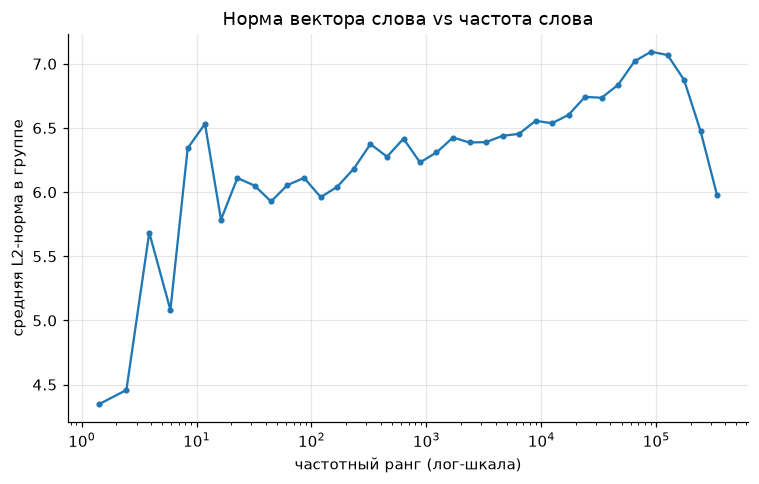

вершина горба: ранг ~90295, норма 7.09


In [ ]:
vocab = model.index_to_key
N = len(vocab)
edges = np.unique(np.geomspace(1, N, 40).astype(int))
rng = np.random.default_rng(42)

centers, means = [], []

for lo, hi in zip(edges[:-1], edges[1:]):
    idxs = np.arange(lo, hi)  # номера слов, попавших в группу
    if len(idxs) > 800:  # большие группы прореживаем, чтобы не ждать
        idxs = rng.choice(idxs, size=800, replace=False)

    norms = np.linalg.norm(model.vectors[idxs], axis=1)

    means.append(norms.mean())

    centers.append(np.sqrt(lo * hi))  # «середина» группы в логарифмической шкале

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(centers, means, marker="o", markersize=3)
ax.set_xscale("log")
ax.set_xlabel("частотный ранг (лог-шкала)")
ax.set_ylabel("средняя L2-норма в группе")
ax.set_title("Норма вектора слова vs частота слова")
plt.tight_layout()
plt.show()

peak_i = np.argmax(means)

peak_rank = centers[peak_i]
print(f"вершина горба: ранг ~{peak_rank:.0f}, норма {means[peak_i]:.2f}")

**Вопрос:** горб воспроизвёлся? Где оказалась вершина? Почему на GloVe картинка может отличаться от word2vec?

**Ответ:** да, горб вышел. самая большая средняя норма вышла примерно на ранге 90 тысяч, около 7.1 очев график может быть другим, потому что glove и word2vec обучаются по разному


> **Для ревьюеров:** 0.5 — график нормы от частоты, 0.5 — ответ про вершину и про то, почему на GloVe картинка может отличаться от word2vec. Если горб вышел смазанным или его вовсе не видно, но студент это честно описал и объяснил, — это полный балл, а не минус.


**(3 балла) Задание 6:** Давайте попробуем сравнить косинусную метрику с евклидовым расстоянием.

1. **(0.5)** Напишите руками `cosine_similarity(u, v)` и `euclidean_distance(u, v)`. Для этого достаточно вбить формулы с лекции в `numpy`. Сверьте свой косинус с `model.similarity`.

2. **(0.5)** Возьмите в качестве якорного слова `anchor_word = "good"` и 10 случайных слов из первых 5000 — берите их через `rng = np.random.default_rng(0)`, чтобы у всех получился один и тот же набор. Убедитесь численно, что $\|\hat u - \hat v\|^2 = 2 - 2\cos(u, v)$, где шляпка — вектор, поделённый на свою длину.

3. **(1)** Проранжируйте первые 5000 слов по близости к якорному тремя способами: по косинусу, по евклидову расстоянию на сырых векторах и по евклидову расстоянию на нормированных векторах.

4. **(0.5)** Найдите 5 слов, где ранги `cos` и `euc_raw` разошлись сильнее всего, и выведите их нормы рядом с нормой якорного слова.

Ещё **0.5** — за ответ на вопрос ниже.


In [ ]:
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


def euclidean_distance(u, v):
    return np.linalg.norm(u - v)


anchor_word = "good"
anchor_vector = model[anchor_word].astype(float)
anchor_norm = np.linalg.norm(anchor_vector)

manual_cosine = cosine_similarity(anchor_vector, model["bad"])
gensim_cosine = model.similarity(anchor_word, "bad")
print("косинус по формуле:", manual_cosine, "gensim:", gensim_cosine)
print("косинусы совпадают:", np.isclose(manual_cosine, gensim_cosine))

rng = np.random.default_rng(0)
sample_words = rng.choice(model.index_to_key[:5000], size=10, replace=False)
normalized_anchor = anchor_vector / anchor_norm
checks = []

for word in sample_words:
    vector = model[word].astype(float)
    normalized_vector = vector / np.linalg.norm(vector)
    distance_squared = euclidean_distance(normalized_anchor, normalized_vector) ** 2
    cosine_expression = 2 - 2 * cosine_similarity(anchor_vector, vector)
    checks.append(
        {
            "word": word,
            "distance_squared": distance_squared,
            "2 - 2 * cosine": cosine_expression,
            "difference": abs(distance_squared - cosine_expression),
        }
    )

checks = pd.DataFrame(checks)
display(checks)
print(
    "равенство выполнено:",
    np.allclose(checks["distance_squared"], checks["2 - 2 * cosine"]),
)

words = model.index_to_key[:5000]
vectors = model.vectors[:5000].astype(float)
vector_norms = np.linalg.norm(vectors, axis=1)
normalized_vectors = vectors / vector_norms[:, None]

scores = pd.DataFrame(
    {
        "word": words,
        "cos": normalized_vectors @ normalized_anchor,
        "euc_raw": np.linalg.norm(vectors - anchor_vector, axis=1),
        "euc_normalized": np.linalg.norm(
            normalized_vectors - normalized_anchor, axis=1
        ),
        "norm": vector_norms,
    }
)
scores = scores[scores["word"] != anchor_word].copy()
scores["cos_rank"] = scores["cos"].rank(ascending=False, method="first").astype(int)
scores["euc_raw_rank"] = scores["euc_raw"].rank(method="first").astype(int)
scores["euc_normalized_rank"] = (
    scores["euc_normalized"].rank(method="first").astype(int)
)

top_words = pd.DataFrame(
    {
        "cos": scores.sort_values("cos_rank")["word"].head(10).tolist(),
        "euc_raw": scores.sort_values("euc_raw_rank")["word"].head(10).tolist(),
        "euc_normalized": scores.sort_values("euc_normalized_rank")["word"]
        .head(10)
        .tolist(),
    },
    index=range(1, 11),
)
display(top_words)
print(
    "cos и euc_normalized совпадают:",
    np.array_equal(scores["cos_rank"], scores["euc_normalized_rank"]),
)
print(
    "cos и euc_raw совпадают:",
    np.array_equal(scores["cos_rank"], scores["euc_raw_rank"]),
)

scores["rank_difference"] = abs(scores["cos_rank"] - scores["euc_raw_rank"])
largest_differences = scores.nlargest(5, "rank_difference").copy()
largest_differences["anchor_norm"] = anchor_norm
display(
    largest_differences[
        [
            "word",
            "cos_rank",
            "euc_raw_rank",
            "rank_difference",
            "norm",
            "anchor_norm",
        ]
    ]
)

косинус по формуле: 0.6445219669406645 gensim: 0.64452195
косинусы совпадают: True


,word,distance_squared,2 - 2 * cosine,difference
0,conservation,1.662839,1.662839,2.220446e-16
1,persons,1.720769,1.720769,2.220446e-16
2,tobacco,1.741129,1.741129,2.220446e-16
3,empire,1.750184,1.750184,4.440892e-16
4,formed,1.734519,1.734519,2.220446e-16
5,around,1.191438,1.191438,0.000000e+00
6,years,1.125586,1.125586,2.220446e-16
7,rising,1.589564,1.589564,0.000000e+00
8,accused,1.714416,1.714416,2.220446e-16
9,july,1.595757,1.595757,0.000000e+00


равенство выполнено: True


,cos,euc_raw,euc_normalized
1,better,better,better
2,really,well,really
3,always,always,always
4,you,really,you
5,well,sure,well
6,excellent,way,excellent
7,very,so,very
8,things,but,things
9,think,excellent,think
10,way,certainly,way


cos и euc_normalized совпадают: True
cos и euc_raw совпадают: False


,word,cos_rank,euc_raw_rank,rank_difference,norm,anchor_norm
11,-,1466,4824,3358,8.984141,5.642854
612,coach,927,3949,3022,8.214435,5.642854
3114,subsequently,4656,1635,3021,4.823364,5.642854
366,cup,1633,4636,3003,8.483219,5.642854
2997,respectively,4348,1380,2968,4.756185,5.642854


**Вопрос:** одно ранжирование совпало с косинусным точь-в-точь, другое — примерно. Почему? Что общего у слов из топ-5 расхождений? Правда ли, что евклидово расстояние «хуже» косинуса?

**Ответ:** нормировка евклидова расстояния дает тако же порядок как и косинусное тк оба зависят от угла между векторами. без нормировки очевидно будет влиять еще и длина. у слов общее это отличие в длине от good (как меньше так и больше). евклидово расстояние не хуже ничем просто оно учитывает длину


## 3. От вектора к матрице

До сих пор слова шли поштучно: длина одного, угол между двумя, среднее нескольких. Теперь возьмём набор целиком и сложим векторы в матрицу $X$ размера $n \times 300$.


**(1 балл) Задание 7:** Матрица Грама, $G$ описывает похожесть между векторами. Будем считать её по формуле

$G = \tilde X \tilde X^\top$, где у матрицы $\tilde X$ все строки нормированы к единичной длине. Тогда $G_{ij}$ — это косинус угла между $i$-м и $j$-м словом.

1. Возьмите 8 слов: четыре про спорт и четыре про готовку.
2. Соберите из них матрицу $X$ и поделите каждую строку на её норму.
3. Посчитайте $G$ и нарисуйте с помощью `sns.heatmap`


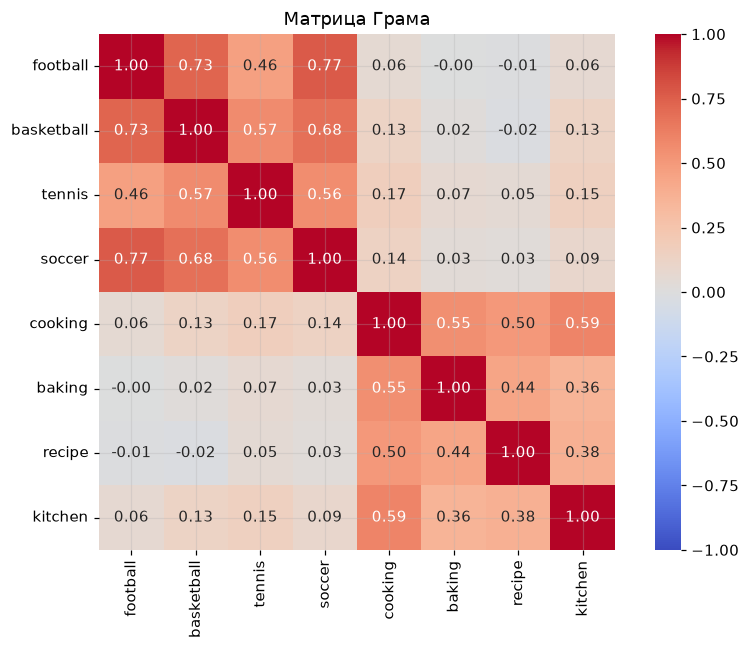

In [ ]:
words = [
    "football",
    "basketball",
    "tennis",
    "soccer",
    "cooking",
    "baking",
    "recipe",
    "kitchen",
]
vectors = model[words]
normalized_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
gram_matrix = normalized_vectors @ normalized_vectors.T

plt.figure(figsize=(8, 6))
sns.heatmap(
    gram_matrix,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Матрица Грама")
plt.tight_layout()
plt.show()

**Вопрос:** что стоит на диагонали $G$? Видно ли на картинке, что слова выделяют две темы? По каким числам вы это поняли?

**Ответ:** на диагонали 1 тк сравнение с самим собой. темы видны так как слова про спорт похожи друг на друга а слова про готовку тоже


**(1 балл) Задание 8:** Ранг матрицы измеряет то, сколько в наборе векторов независимых направлений.

1. Возьмите первые 300 слов, соберите матрицу $300 \times 300$ и посчитайте `np.linalg.matrix_rank`.
2. Повторите это для `ns = [50, 100, 200, 299, 300, 301, 500, 1000]` и нарисуйте: по X число слов, по Y ранг.


ранг первых 300 слов: 300


число слов: [50, 100, 200, 299, 300, 301, 500, 1000]
ранг: [50, 100, 200, 299, 300, 300, 300, 300]


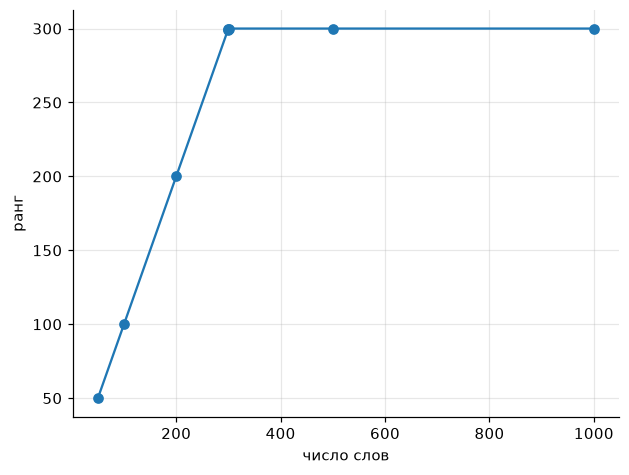

In [ ]:
vectors = model.vectors[:300].astype(float)
print("ранг первых 300 слов:", np.linalg.matrix_rank(vectors))

ns = [50, 100, 200, 299, 300, 301, 500, 1000]
ranks = []
for number_of_words in ns:
    ranks.append(
        int(np.linalg.matrix_rank(model.vectors[:number_of_words].astype(float)))
    )

print("число слов:", ns)
print("ранг:", ranks)
plt.plot(ns, ranks, marker="o")
plt.xlabel("число слов")
plt.ylabel("ранг")
plt.show()

**Вопрос:** почему график упирается в потолок и что это за уровень? Можно ли подобрать слова так, чтобы ранг стал больше?

**Ответ:** ранг не растет потому что у вектора 300 чисел соответвенно даже если мы слова и подберем другие все равно выше 300 ранг не вырастет


**(1.5 балла) Задание 9:** Немного поработаем с определителем. С помощью него можно понимать, есть ли в наборе векторов линейная зависимость.

Определитель матрицы Грама $\det G$ можно проинтерпретировать как квадрат объёма параллелепипеда, натянутого на наши векторы. Если векторы ложатся в одну плоскость, объем оказывается почти нулевым и определитель тоже.

1. Напишите функцию `gram_det(words)`. Внутри неё векторы должны собираться в матрицу, дальше должна происходить нормировка строк, после найдите $G$ и посчитайте её определитель.
2. Прогоните через получившуюся функцию тройки слов, выписанные ниже.


In [ ]:
def gram_det(words):
    vectors = model[words].astype(float)
    normalized_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    gram_matrix = normalized_vectors @ normalized_vectors.T
    return np.linalg.det(gram_matrix)


triples = {
    "синонимы   happy/joyful/glad": ["happy", "joyful", "glad"],
    "синонимы   big/large/huge": ["big", "large", "huge"],
    "случайные  king/banana/quantum": ["king", "banana", "quantum"],
    "случайные  car/philosophy/rain": ["car", "philosophy", "rain"],
    "своя       cat/dog/kitten": ["cat", "dog", "kitten"],
}

for name, ws in triples.items():
    d = gram_det(ws)
    print(f"  {name:32s} det(G)={d:.4f}   объём={np.sqrt(max(d, 0)):.4f}")

  синонимы   happy/joyful/glad     det(G)=0.4048   объём=0.6362
  синонимы   big/large/huge        det(G)=0.2315   объём=0.4812
  случайные  king/banana/quantum   det(G)=0.9869   объём=0.9934
  случайные  car/philosophy/rain   det(G)=0.9771   объём=0.9885
  своя       cat/dog/kitten        det(G)=0.4296   объём=0.6554


**Вопрос:** у кого $\det G$ больше, у синонимов или у случайных слов? Почему?

**Ответ:** у случайных слов, так как у синонимвов векторы похожи -> объем меньше
